In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [33]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2026, 1, 1)

df = yf.download(stock, start, end)


/tmp/ipython-input-215/704684613.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


In [34]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2025-12-24,265.074188,267.051985,263.343616,264.826964,6131188
2025-12-26,262.503082,266.310317,261.909737,265.024761,6029003
2025-12-29,257.706940,263.492002,257.113595,262.997552,7270521
2025-12-30,257.459717,258.547511,256.075265,257.113596,10929200
2025-12-31,261.662537,262.255882,257.657480,258.498050,5145868


In [35]:
df.shape

(4497, 5)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4497 entries, 2007-10-05 to 2025-12-31
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4497 non-null   float64
 1   (High, POWERGRID.NS)    4497 non-null   float64
 2   (Low, POWERGRID.NS)     4497 non-null   float64
 3   (Open, POWERGRID.NS)    4497 non-null   float64
 4   (Volume, POWERGRID.NS)  4497 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 210.8 KB


In [37]:
df.isnull().sum()

,,0
Price,Ticker,
Close,POWERGRID.NS,0
High,POWERGRID.NS,0
Low,POWERGRID.NS,0
Open,POWERGRID.NS,0
Volume,POWERGRID.NS,0


In [38]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4497.000000,4497.000000,4497.000000,4497.000000,4.497000e+03
mean,89.314343,90.438298,88.214628,89.360428,1.192376e+07
std,78.322004,79.190738,77.448384,78.335933,2.000921e+07
min,18.038853,19.282911,16.172765,19.189606,0.000000e+00
25%,35.129803,35.675626,34.665427,35.189642,4.966775e+06
50%,64.601555,65.485833,63.747412,64.661430,8.581053e+06
75%,100.171822,101.280509,99.302269,100.410954,1.377788e+07
max,344.843262,345.598137,337.058457,343.522181,8.552157e+08


In [39]:
df = df.reset_index()

In [40]:
df.columns

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [46]:
df.to_csv("powergrid.csv")

In [47]:
data01 = pd.read_csv("powergrid.csv")

In [48]:
data01.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,30.896223068237305,33.62958736246396,25.53698711802173,27.579332665029565,855215656
2,1,2007-10-08,29.3145751953125,31.94044832271491,29.130302593015134,31.94044832271491,126671715
3,2,2007-10-09,31.310840606689453,31.58724732063568,27.74825361145258,29.329918186521063,116725709
4,3,2007-10-10,31.602609634399414,32.24756153152194,31.326202868654203,32.12471246013357,67931378


In [49]:
#getting candlesticks
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x= data01['Date'], open = data01['Open'], high = data01['High'], low = data01['Low'], close = data01['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()


In [50]:
df = df.drop(['Date','Adj Close'], axis = 1)

/tmp/ipython-input-215/3608030452.py:1: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



KeyError: 'Adj Close'

In [51]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,2007-10-05,30.896223,33.629587,25.536987,27.579333,855215656
1,2007-10-08,29.314575,31.940448,29.130303,31.940448,126671715
2,2007-10-09,31.310841,31.587247,27.748254,29.329918,116725709
3,2007-10-10,31.602610,32.247562,31.326203,32.124712,67931378
4,2007-10-11,35.134487,36.854358,31.326205,36.854358,106320954


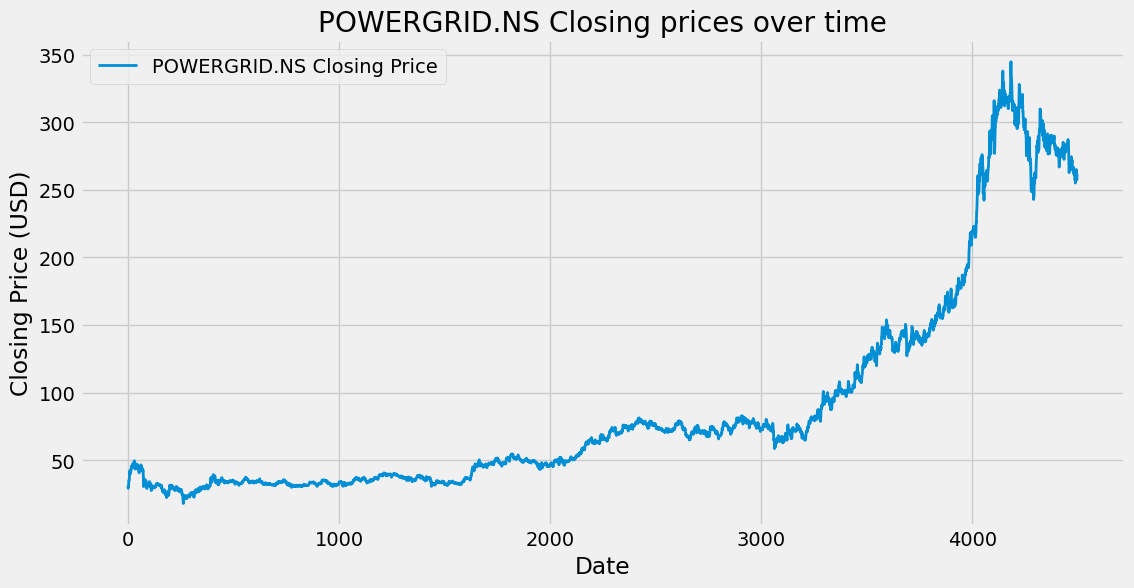

In [52]:
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth =2)
plt.title(f'{stock} Closing prices over time' )
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()

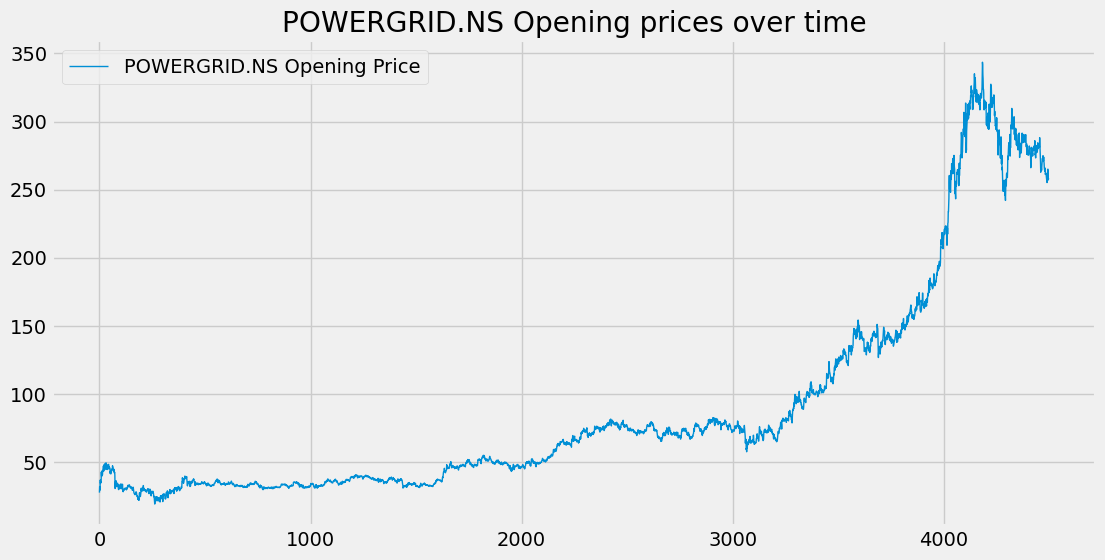

In [53]:
plt.figure(figsize=(12,6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 1)
plt.title(f'{stock} Opening prices over time' )
plt.legend()
plt.show()

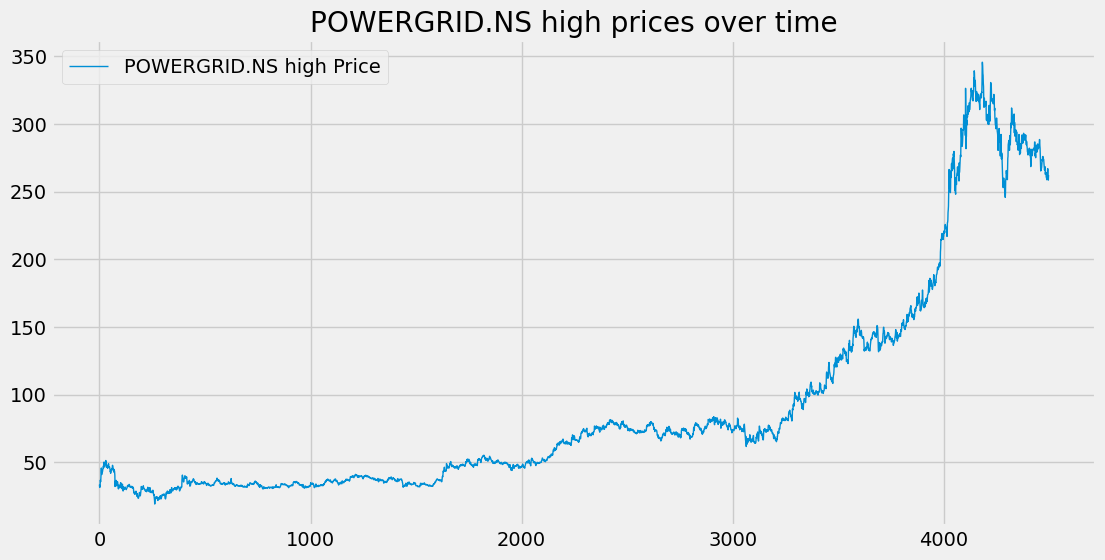

In [54]:
plt.figure(figsize=(12,6))
plt.plot(df['High'], label = f'{stock} high Price', linewidth = 1)
plt.title(f'{stock} high prices over time' )
plt.legend()
plt.show()

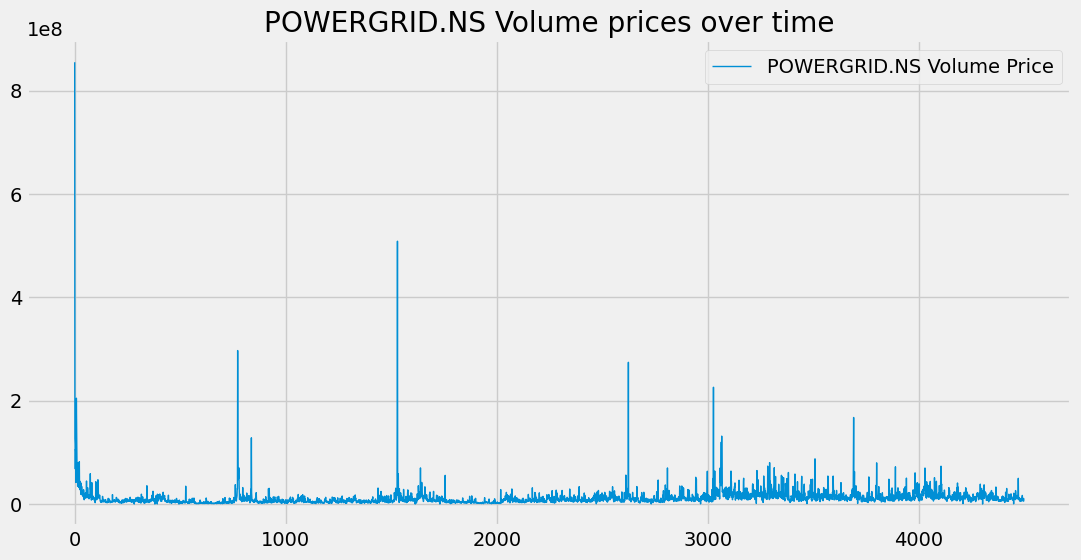

In [55]:
plt.figure(figsize=(12,6))
plt.plot(df['Volume'], label = f'{stock} Volume Price', linewidth = 1)
plt.title(f'{stock} Volume prices over time' )
plt.legend()
plt.show()

In [56]:
#Moving Average
#[10,20,30,40,50,60,70,80,90]

temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90]
print(sum(temp_data[0:5])/5)

30.0


In [57]:
import pandas as pd
df01=pd.DataFrame(temp_data)

In [58]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [59]:
ma100 = df.Close.rolling(100).mean()

In [60]:
ma100

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4492,273.782094
4493,273.589223
4494,273.345970
4495,273.132200


In [61]:
ma200 = df.Close.rolling(200).mean()

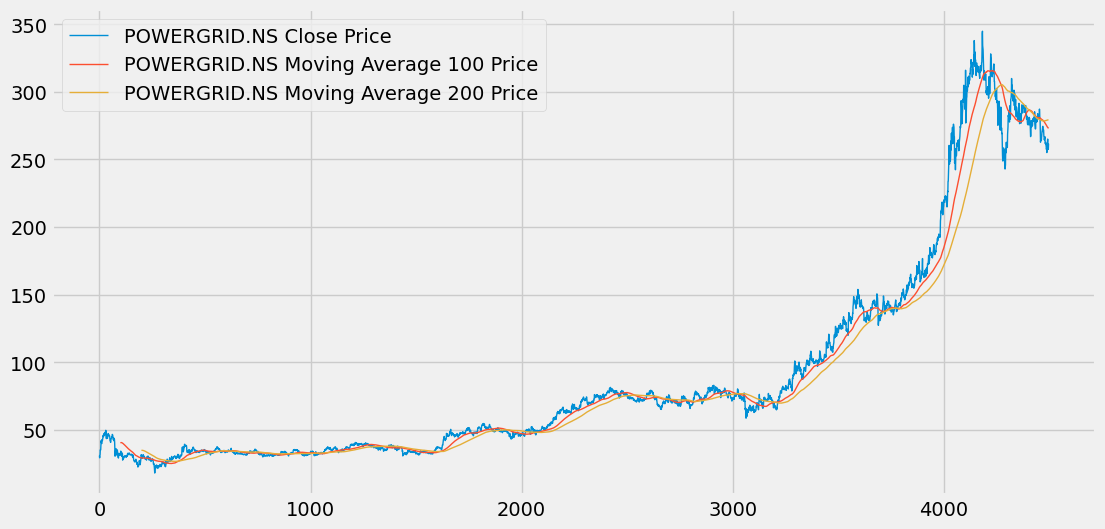

In [67]:
plt.figure(figsize=(12,6))
plt.plot( df.Close, label = f'{stock} Close Price', linewidth =1)
plt.plot(ma100, label = f'{stock} Moving Average 100 Price',linewidth = 1)
plt.plot(ma200, label = f'{stock} Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [69]:
#next 30 days
ema100 = df.Close.ewm(span=100, adjust = False).mean()

In [72]:
ema200 = df['Close'].ewm(span=200, adjust = False).mean()

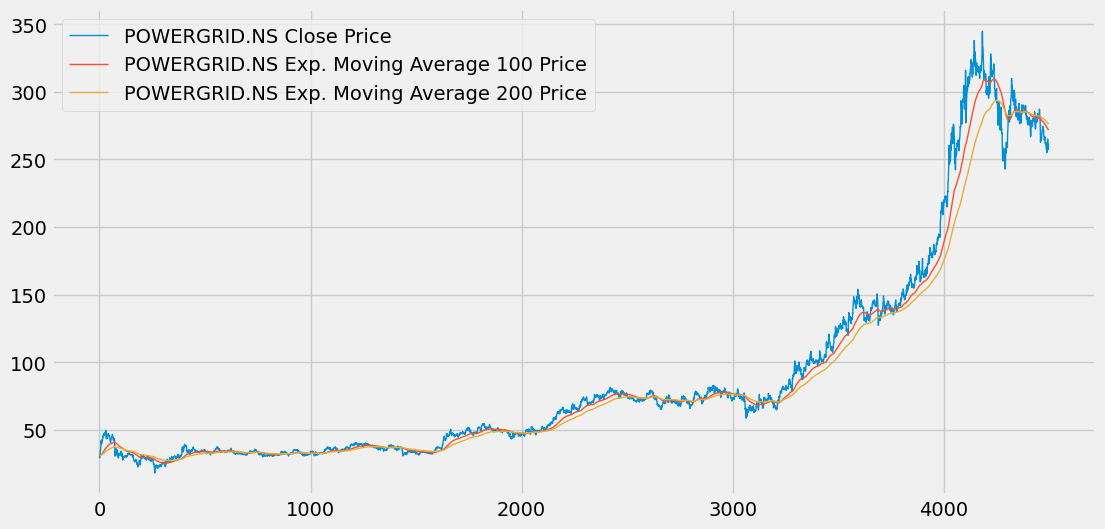

In [73]:
plt.figure(figsize=(12,6))
plt.plot( df.Close, label = f'{stock} Close Price', linewidth =1)
plt.plot(ema100, label = f'{stock} Exp. Moving Average 100 Price',linewidth = 1)
plt.plot(ema200, label = f'{stock} Exp. Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [75]:
# Training & testing
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [77]:
data_training.shape

(3147, 1)

In [78]:
data_testing.shape

(1350, 1)

In [81]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [84]:
data_training_array = scaler.fit_transform(data_training)

In [85]:
data_training_array

array([[0.19808583],
       [0.17371833],
       [0.2044736 ],
       ...,
       [0.74524543],
       [0.74649878],
       [0.81009344]])

In [88]:
x_train = []
y_train =[]

for i in range(100,data_training_array.shape[0]):
  x_train.append(data_training_array[i-100:i])
  y_train.append(data_training_array[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

In [89]:
x_train.shape

(3047, 100, 1)

In [91]:
#model building

from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [94]:
model = Sequential()
model.add(LSTM(units=50, activation = 'relu', return_sequences = True, input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [95]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [99]:
model.compile(optimizer = 'adam', loss ='mean_squared_error')
model.fit(x_train,y_train, epochs = 50)


Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 36s 273ms/step - loss: 0.0928
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 282ms/step - loss: 0.0096
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 273ms/step - loss: 0.0067
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 28s 292ms/step - loss: 0.0063
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 272ms/step - loss: 0.0058
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 275ms/step - loss: 0.0056
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 275ms/step - loss: 0.0061
Epoch 8/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 273ms/step - loss: 0.0050
Epoch 9/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 272ms/step - loss: 0.0053
Epoch 10/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 272ms/step - loss: 0.0066
Epoch 11/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 275ms/step - loss: 0.0040
Epoch 12/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 272ms/step - loss: 0.0042
Epoch 13/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 276ms/step - loss: 0.0045
Epoch 14/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 41s 272ms/step - loss: 0.0038
Epoch 15/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 26s 

In [113]:
past_100_days = data_training.tail(100)

In [119]:
final_df = pd.concat([past_100_days, data_testing], ignore_index = True)

In [120]:
final_df.head()

Ticker,POWERGRID.NS
0,72.997101
1,73.016716
2,72.899040
3,73.134392
4,71.192764


In [121]:
input_data = scaler.fit_transform(final_df)

In [123]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])
x_test, y_test = np.array(x_test), np.array(y_test)


In [124]:
x_test.shape

(1350, 100, 1)

In [126]:
y_predicted = model.predict(x_test)

43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step


In [127]:
y_predicted.shape

(1350, 1)

In [131]:
scaler.scale

AttributeError: 'MinMaxScaler' object has no attribute 'scale'

In [129]:
scaler_factor = 1 / 0.0035166
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor

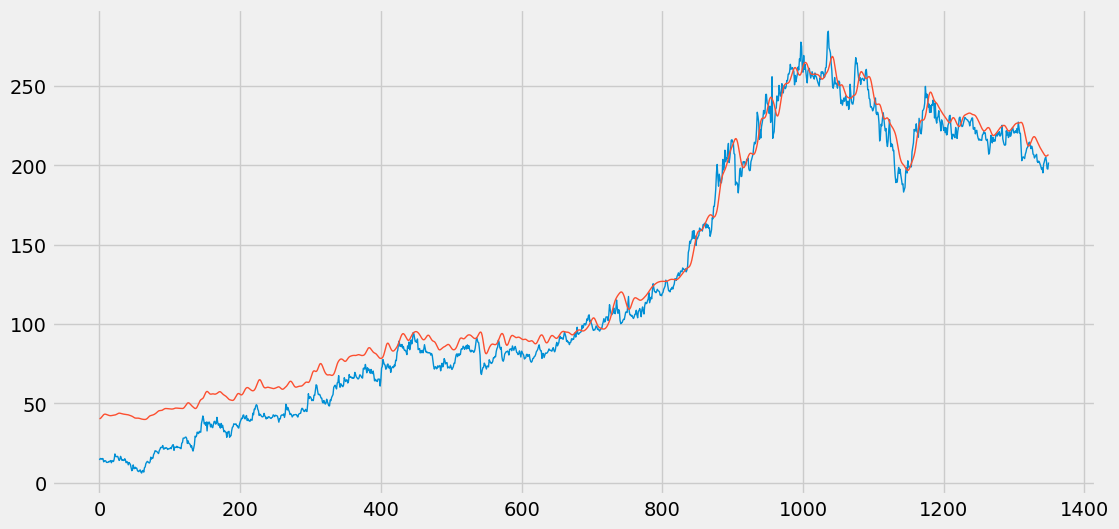

In [135]:
plt.figure(figsize=(12,6))
plt.plot(y_test, label = f' Original Price', linewidth =1)
plt.plot(y_predicted, label = 'Predicted Price',linewidth =1)
plt.show()

In [134]:
model.save('stock_dl_model.h5')